# Task 1a : SDSS Cross-Matching and Exploratory Data Analysis

In this task, we cross-match the Shen et al. (2011) quasar subsample with SDSS DR18 using Plate-MJD-Fiber identifiers in order to obtain:

- Redshift (z)
- Hβ flux

After obtaining the SDSS information, we perform exploratory data analysis (EDA) of the quasar sample by examining:

1. Redshift distribution
2. Hβ FWHM distribution
3. i-band magnitude vs redshift relation

These plots help us understand the physical properties and observational limitations of the sample.

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astroquery.sdss import SDSS
from astropy.table import Table

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Load the Shen et al. quasar sample

In [154]:
df = pd.read_csv('shen_subsample_500.csv')

print(f'Total quasars loaded = {len(df)}')

df.head()

Total quasars loaded = 500


,RAJ2000,DEJ2000,Plate,Fiber,MJD,iMAG,logLbol,e_logLbol,logLBHb,e_logLBHb,W_BHb_,e_W_BHb_,EWBHb,e_EWBHb,SN_Hb_,logBH,e_logBH,logEdd
0,189.67804,45.30687,1372,486,53062,-23.20,45.236,0.004,42.35,0.02,4399.3,330.1,62.0,3.1,23.06,8.33,0.07,-1.20
1,189.77188,41.44564,1984,609,53433,-22.29,44.819,0.005,42.11,0.04,2371.4,541.6,89.4,8.7,15.06,7.59,0.20,-0.87
2,189.81419,53.23740,885,449,52379,-22.69,45.121,0.004,41.93,0.04,10756.6,4366.4,32.1,3.4,16.27,9.05,0.35,-2.03
3,189.93733,19.90707,2614,350,54481,-23.37,45.132,0.001,42.55,0.02,15241.3,362.8,118.7,6.3,19.79,9.36,0.02,-2.33
4,189.99405,49.09448,1278,96,52735,-22.77,45.166,0.011,42.25,0.01,1385.6,48.6,52.5,2.9,15.96,7.29,0.03,-0.23


## Cross-match with SDSS DR18

We use the Plate-MJD-Fiber identifiers to query SDSS spectra and obtain:

- redshift (z)
- Hβ line flux

In [155]:
import time

def get_sdss_data(df):

    all_results = []

    unique_objects = df[['Plate','MJD','Fiber']].drop_duplicates()

    print(f'Total unique objects = {len(unique_objects)}')

    for i, row in unique_objects.iterrows():

        try:

            xid = SDSS.query_specobj(
                plate=int(row['Plate']),
                mjd=int(row['MJD']),
                fiberID=int(row['Fiber'])
            )

            if xid is not None:

                result = xid.to_pandas()

                result['Plate'] = row['Plate']
                result['MJD'] = row['MJD']
                result['Fiber'] = row['Fiber']

                all_results.append(result)

        except:
            continue

        if (i+1) % 50 == 0:
            print(f'Processed {i+1} objects')

        time.sleep(0.1)

    return pd.concat(all_results, ignore_index=True)

In [156]:
try:

    df_sdss = get_sdss_data(df)

    print('SDSS query successful')

except Exception as e:

    print(f'SDSS query failed : {e}')

    print('Loading backup file...')

    df_sdss = pd.read_csv('shen_sample_with_flux.csv')

Total unique objects = 500
Processed 50 objects
Processed 100 objects
Processed 150 objects
Processed 200 objects
Processed 250 objects
Processed 300 objects
Processed 350 objects
Processed 400 objects
Processed 450 objects
Processed 500 objects
SDSS query successful


## Match SDSS parameters with original catalog

In [157]:
df['key'] = (
    df['Plate'].astype(str)
    + '-'
    + df['MJD'].astype(str)
    + '-'
    + df['Fiber'].astype(str)
)

df_sdss['key'] = (
    df_sdss['plate'].astype(str)
    + '-'
    + df_sdss['mjd'].astype(str)
    + '-'
    + df_sdss['fiberID'].astype(str)
)

z_map = df_sdss.groupby('key')['z'].first().to_dict()

df['z'] = df['key'].map(z_map)

print(f'Matched objects = {df["z"].notna().sum()}')
print(f'Redshift range: {df["z"].min():.3f} - {df["z"].max():.3f}')
print(f'Poor FWHM (>10000 km/s): {(df["W_BHb_"] > 10000).sum()}')

print(f'FWHM < 2000 km/s: {(df["W_BHb_"] < 2000).sum()}')

Matched objects = 499
Redshift range: 0.064 - 0.300
Poor FWHM (>10000 km/s): 31
FWHM < 2000 km/s: 59


# Exploratory Data Analysis (EDA)

## Redshift Distribution

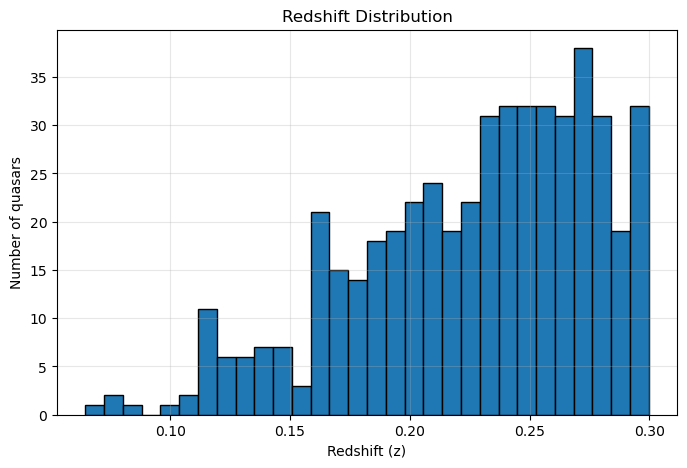

In [158]:
plt.figure(figsize=(8,5))

plt.hist(
    df['z'].dropna(),
    bins=30,
    edgecolor='black'
)

plt.xlabel('Redshift (z)')
plt.ylabel('Number of quasars')

plt.title('Redshift Distribution')

plt.grid(alpha=0.3)

plt.show()

## Hβ FWHM Distribution

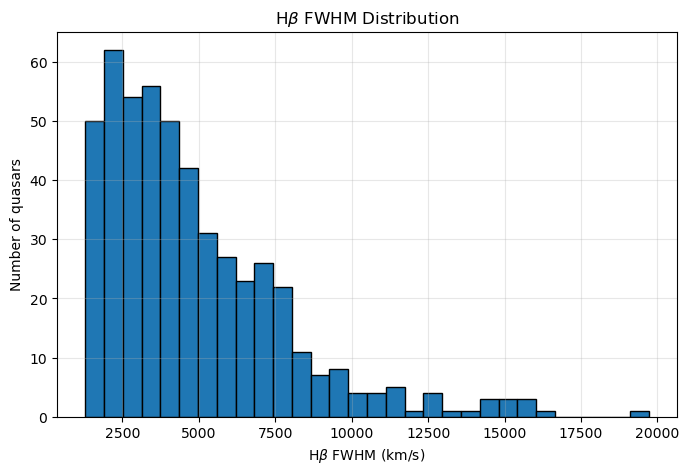

In [159]:
plt.figure(figsize=(8,5))

plt.hist(
    df['W_BHb_'].dropna(),
    bins=30,
    edgecolor='black'
)

plt.xlabel(r'H$\beta$ FWHM (km/s)')
plt.ylabel('Number of quasars')

plt.title(r'H$\beta$ FWHM Distribution')

plt.grid(alpha=0.3)

plt.show()

## i-band Magnitude vs Redshift

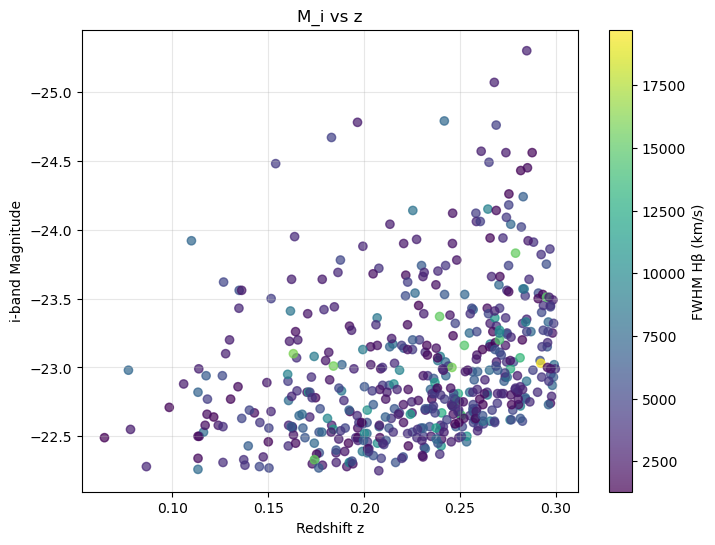

In [95]:
plt.figure(figsize=(8,6))

sc = plt.scatter(
    df['z'],
    df['iMAG'],
    c=df['W_BHb_'],      
    cmap='viridis',
    alpha=0.7
)

plt.xlabel('Redshift z')
plt.ylabel('i-band Magnitude')

plt.title('M_i vs z')

plt.gca().invert_yaxis()

cbar = plt.colorbar(sc)
cbar.set_label('FWHM Hβ (km/s)')

plt.grid(alpha=0.3)

plt.show()

## FWHM versus Redshift

This plot shows how the Hβ FWHM changes with redshift.

The color scale represents the i-band magnitude of quasars. 
This helps visualize whether broader emission lines are associated with brighter or fainter quasars.

A logarithmic scale is used for FWHM because the velocity range spans several thousand km/s.

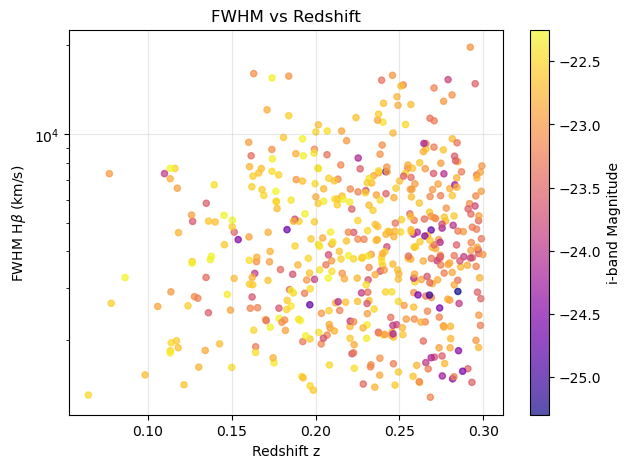

In [96]:
df_plot = df.dropna(subset=['z','W_BHb_','iMAG'])

plt.figure(figsize=(7,5))

sc = plt.scatter(
    df_plot['z'],
    df_plot['W_BHb_'],
    c=df_plot['iMAG'],
    cmap='plasma',
    s=20,
    alpha=0.7
)

plt.yscale('log')

plt.xlabel('Redshift z')
plt.ylabel(r'FWHM H$\beta$ (km/s)')

plt.title('FWHM vs Redshift')

cbar = plt.colorbar(sc)
cbar.set_label('i-band Magnitude')

plt.grid(alpha=0.3)

plt.show()

## Discussion

The redshift distribution shows that most quasars are concentrated at moderate redshifts (z ≈ 0.2–0.3), with fewer objects at lower redshifts.

The Hβ FWHM distribution spans a broad range of velocities, indicating diversity in broad-line region dynamics and black hole masses among the quasars.

The i-band magnitude versus redshift plot suggests that higher-redshift quasars generally appear fainter due to cosmological dimming and observational selection effects.

The FWHM versus redshift plot does not show a strong correlation between line width and redshift, although a wide spread in FWHM values is observed throughout the sample.

Overall, the sample reflects both intrinsic quasar properties and observational limitations of SDSS spectroscopy.

## Task 1b : Luminosity Distance and Hβ Luminosity

We calculate the luminosity distance using the cosmological relations from Hogg (2000) with Planck cosmology parameters:

$
H_0 = 67.8 \ \mathrm{km \ s^{-1} \ Mpc^{-1}}
$

$
\Omega_m = 0.31
$

$
\Omega_\Lambda = 0.69
$

The luminosity distance was converted from Mpc to cm using:

$
1 \ \mathrm{Mpc} = 3.0857 \times 10^{24} \ \mathrm{cm}
$

The $ H\beta\ $ luminosity values were obtained from the provided Shen catalog luminosities (`logLBHb`) through:

$
L_{H\beta} = 10^{\log L_{H\beta}}
$

In [151]:
# Luminosity Distance and Hβ Luminosity
import numpy as np
import pandas as pd
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=67.8, Om0=0.31)

#Calculate luminosity distance


df_clean['DL_Mpc'] = (
    cosmo.luminosity_distance(df_clean['z']).value
)

# Convert distance from Mpc to cm
# 1 Mpc = 3.0857 × 10^24 cm


df_clean['DL_cm'] = (
    df_clean['DL_Mpc'] * 3.0857e24
)

df_clean['L_Hb'] = 10**df_clean['logLBHb']

# logarithmic luminosity
df_clean['logL_Hb'] = np.log10(df_clean['L_Hb'])

print("Hβ luminosity calculated successfully")

df_clean[
    [
        'z',
        'DL_Mpc',
        'DL_cm',
        'logLBHb',
        'L_Hb',
        'logL_Hb'
    ]
].head()

Hβ luminosity calculated successfully


,z,DL_Mpc,DL_cm,logLBHb,L_Hb,logL_Hb
0,0.228846,1175.128117,3.626093e+27,42.35,2.238721e+42,42.35
1,0.178252,889.116854,2.743548e+27,42.11,1.288250e+42,42.11
2,0.201624,1019.537956,3.145988e+27,41.93,8.511380e+41,41.93
3,0.239360,1236.253620,3.814708e+27,42.55,3.548134e+42,42.55
4,0.235311,1212.643651,3.741855e+27,42.25,1.778279e+42,42.25


## Black Hole Mass Estimation

The black hole mass was estimated using the empirical virial relation from Wu et al. (2009), based on the H\beta\ luminosity and the FWHM of the broad H\beta\ emission line.

The relation is:
$
M_{BH} =
2.4 \times 10^6
\left(
\frac{L_{H\beta}}{10^{42}\ \mathrm{erg\ s^{-1}}}
\right)^{0.59}
\left(
\frac{\mathrm{FWHM}_{H\beta}}{10^3\ \mathrm{km\ s^{-1}}}
\right)^2
M_\odot
$

This method assumes that the broad-line region (BLR) gas is virialized and that the H\beta\ line width traces the gravitational motion around the black hole.

In [152]:
# Black Hole Mass Calculation using Wu (2009)
# Virial black hole mass relation

M_BH = (
    2.4e6 *
    (df_clean['L_Hb'] / 1e42)**0.59 *
    (df_clean['W_BHb_'] / 1e3)**2
)

df_clean['logM_BH_our'] = np.log10(M_BH)

df_clean['M_BH_our'] = M_BH

print("Black hole masses calculated successfully")

df_clean[
    [
        'L_Hb',
        'W_BHb_',
        'M_BH_our',
        'logM_BH_our'
    ]
].head()

Black hole masses calculated successfully


,L_Hb,W_BHb_,M_BH_our,logM_BH_our
0,2.238721e+42,4399.3,7.472715e+07,7.873478
1,1.288250e+42,2371.4,1.567187e+07,7.195121
2,8.511380e+41,10756.6,2.524999e+08,8.402261
3,3.548134e+42,15241.3,1.176943e+09,9.070755
4,1.778279e+42,1385.6,6.471232e+06,6.810987


## Bolometric Luminosity Estimation

The bolometric luminosity was estimated using the empirical relation from Wu et al. (2009), which connects the H\beta\ luminosity with the total bolometric luminosity of the AGN.

The relation is:
$
\log L_{bol}
=
0.94 \log L_{H\beta}
+
5.39
$
where:

$
L_{bol}
$
is the bolometric luminosity in erg s\(^{-1}\), and
$
L_{H\beta}
$
is the $ H\beta\ $ emission-line luminosity.

The linear bolometric luminosity was then obtained through:
$
L_{bol} = 10^{\log L_{bol}}
$

In [125]:
# Bolometric Luminosity Calculation
# Using Wu (2009) empirical relation

df_clean['logL_bol'] = (
    0.94 * df_clean['logL_Hb'] + 5.39
)

# Convert to linear luminosity

df_clean['L_bol'] = 10**df_clean['logL_bol']

print("Bolometric luminosities calculated successfully")

df_clean[
    [
        'logL_Hb',
        'logL_bol',
        'L_bol'
    ]
].head()

Bolometric luminosities calculated successfully


,logL_Hb,logL_bol,L_bol
0,42.35,45.1990,1.581248e+45
1,42.11,44.9734,9.405892e+44
2,41.93,44.8042,6.370888e+44
3,42.55,45.3870,2.437811e+45
4,42.25,45.1050,1.273503e+45


## Eddington Luminosity and Eddington Ratio

The Eddington luminosity represents the maximum luminosity at which radiation pressure balances gravitational attraction for spherical accretion onto the black hole.

It was calculated using:

$
L_{Edd}
=
1.26 \times 10^{38}
\left(
\frac{M_{BH}}{M_\odot}
\right)
\ \mathrm{erg\ s^{-1}}
$

where:
$
M_{BH}
$
is the black hole mass in solar masses.

The Eddington ratio was then estimated as:

$
\lambda_{Edd}
=
\frac{L_{bol}}{L_{Edd}}
$

The logarithmic Eddington ratio was finally calculated through:

$
\log \lambda_{Edd}
=
\log
\left(
\frac{L_{bol}}{L_{Edd}}
\right)
$

In [126]:
# Eddington Luminosity and Eddington Ratio

df_clean['L_Edd'] = (
    1.26e38 * df_clean['M_BH_our']
)

# Calculate Eddington ratio

df_clean['lambda_Edd'] = (
    df_clean['L_bol'] /
    df_clean['L_Edd']
)


df_clean['logLambda_Edd'] = np.log10(
    df_clean['lambda_Edd']
)
print("Eddington ratios calculated successfully")

df_clean[
    [
        'L_bol',
        'L_Edd',
        'lambda_Edd',
        'logLambda_Edd'
    ]
].head()

Eddington ratios calculated successfully


,L_bol,L_Edd,lambda_Edd,logLambda_Edd
0,1.581248e+45,9.415620e+45,0.167939,-0.774849
1,9.405892e+44,1.974656e+45,0.476331,-0.322091
2,6.370888e+44,3.181499e+46,0.020025,-1.698432
3,2.437811e+45,1.482948e+47,0.016439,-1.784126
4,1.273503e+45,8.153753e+44,1.561861,0.193642


## Eddington Ratio versus Black Hole Mass

To investigate the accretion properties of the AGN sample, the Eddington ratio was plotted against the estimated black hole mass.

This relation helps us understand how efficiently the supermassive black holes are accreting matter relative to their Eddington limit.

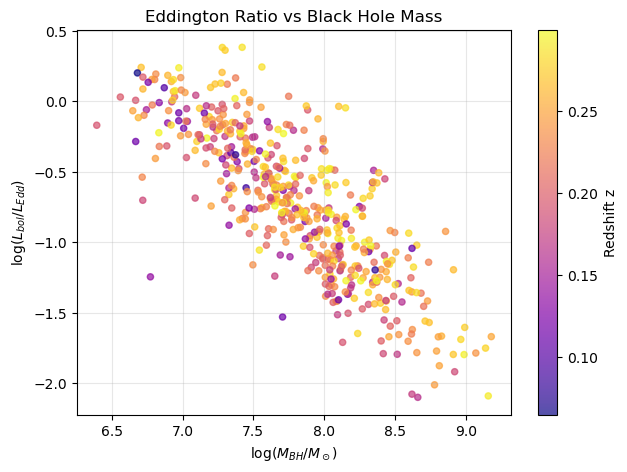

In [120]:
# Eddington Ratio vs Black Hole Mass
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sc = plt.scatter(
    df_clean['logM_BH_our'],
    df_clean['logLambda_Edd'],
    c=df_clean['z'],
    cmap='plasma',
    s=20,
    alpha=0.7
)

plt.xlabel(r'log($M_{BH}/M_\odot$)')
plt.ylabel(r'log($L_{bol}/L_{Edd}$)')

plt.title('Eddington Ratio vs Black Hole Mass')

cbar = plt.colorbar(sc)
cbar.set_label('Redshift z')

plt.grid(alpha=0.3)

plt.show()

## Assumptions and Limitations

The virial black hole mass relation assumes that the BLR gas is virialized and dominated by the gravity of the central black hole.

The $ H\beta\$  FWHM is assumed to trace the BLR gas velocity, and the luminosity–BLR size relation is assumed to remain valid for this AGN sample.

The AGN emission is assumed to be isotropic, while dust extinction, host galaxy contamination, and orientation effects are neglected.

The empirical scaling relations also contain intrinsic uncertainties, which may affect the estimated black hole masses and Eddington ratios.

# 1c. Black Hole Mass and Eddington Ratio Analysis

The obtained black hole masses indicate that these AGNs host supermassive black holes with masses typically ranging from about $10^7$ to $10^9 \ M_\odot\$.

The calculated Eddington ratios are mostly below unity, suggesting that the sources are accreting in the sub-Eddington regime. This implies relatively stable accretion rather than extremely rapid black hole growth.

The AGNs therefore appear to be luminous broad-line AGNs powered by actively accreting supermassive black holes.

In [127]:
df_clean['FWHM_Hb'] = df_clean['W_BHb_']

In [128]:
M_BH = (
    2.4e6 *
    (df_clean['L_Hb'] / 1e42)**0.59 *
    (df_clean['FWHM_Hb'] / 1e3)**2
)

df_clean['logM_BH_our'] = np.log10(M_BH)

df_clean['logM_ref'] = df_clean['logBH']

In [129]:
print('Black Hole Mass Statistics:\n')

print(f'Our mean log(M_BH) = {df_clean["logM_BH_our"].mean():.2f}')

print(f'Shen mean log(M_BH) = {df_clean["logM_ref"].mean():.2f}')

Black Hole Mass Statistics:

Our mean log(M_BH) = 7.79
Shen mean log(M_BH) = 8.26


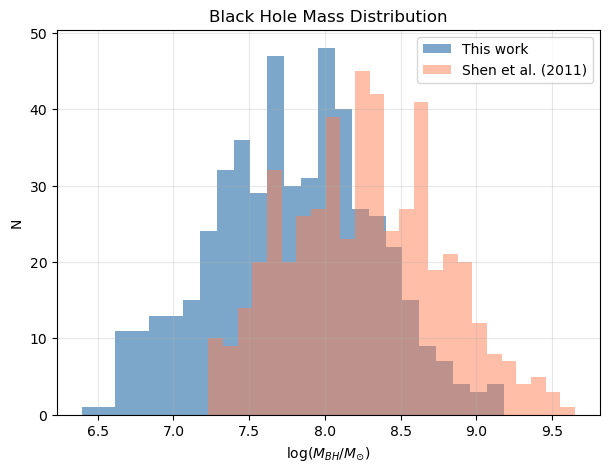

In [130]:
plt.figure(figsize=(7,5))

plt.hist(
    df_clean['logM_BH_our'],
    bins=25,
    alpha=0.7,
    label='This work',
    color='steelblue'
)

plt.hist(
    df_clean['logM_ref'],
    bins=25,
    alpha=0.5,
    label='Shen et al. (2011)',
    color='coral'
)

plt.xlabel(r'log($M_{BH}/M_{\odot}$)')

plt.ylabel('N')

plt.title('Black Hole Mass Distribution')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

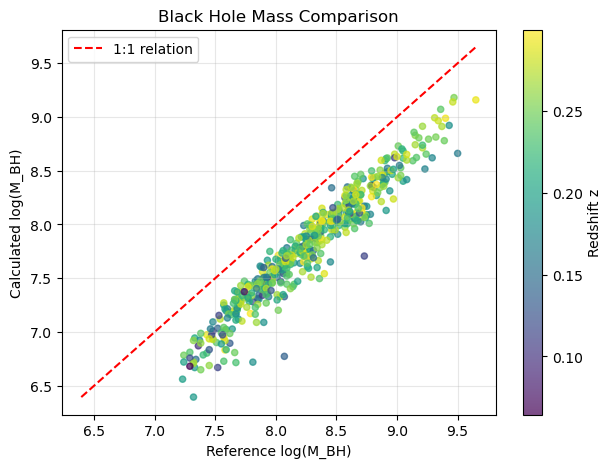

In [131]:
plt.figure(figsize=(7,5))

sc = plt.scatter(
    df_clean['logM_ref'],
    df_clean['logM_BH_our'],
    c=df_clean['z'],
    cmap='viridis',
    s=20,
    alpha=0.7
)

lims = [
    min(df_clean['logM_ref'].min(),
        df_clean['logM_BH_our'].min()),

    max(df_clean['logM_ref'].max(),
        df_clean['logM_BH_our'].max())
]

plt.plot(lims, lims, 'r--', label='1:1 relation')

plt.xlabel('Reference log(M_BH)')

plt.ylabel('Calculated log(M_BH)')

plt.title('Black Hole Mass Comparison')

plt.legend()

cbar = plt.colorbar(sc)
cbar.set_label('Redshift z')

plt.grid(alpha=0.3)

plt.show()

## Bolometric Luminosity

Using Wu (2009):

$
\log L_{bol}
=
0.94 \log L_{H\beta}
+
5.39
$

In [132]:
df_clean['logL_bol'] = (
    0.94 * df_clean['logL_Hb'] + 5.39
)

df_clean['L_bol'] = 10**df_clean['logL_bol']

The Eddington luminosity is:

$
L_{Edd}
=
1.26 \times 10^{38}
\left(
\frac{M_{BH}}{M_{\odot}}
\right)
$

In [52]:
L_EDD = 1.26e38

df_clean['L_Edd'] = (
    L_EDD * 10**df_clean['logM_BH_our']
)

The Eddington ratio is:

$
\lambda_{Edd}
=
\frac{L_{bol}}{L_{Edd}}
$

In [133]:
df_clean['lambda_Edd'] = (
    df_clean['L_bol'] /
    df_clean['L_Edd']
)

df_clean['logLambda_Edd'] = np.log10(
    df_clean['lambda_Edd']
)

print(
    f'Mean log λ_Edd = {df_clean["logLambda_Edd"].mean():.2f}'
)

Mean log λ_Edd = -0.72


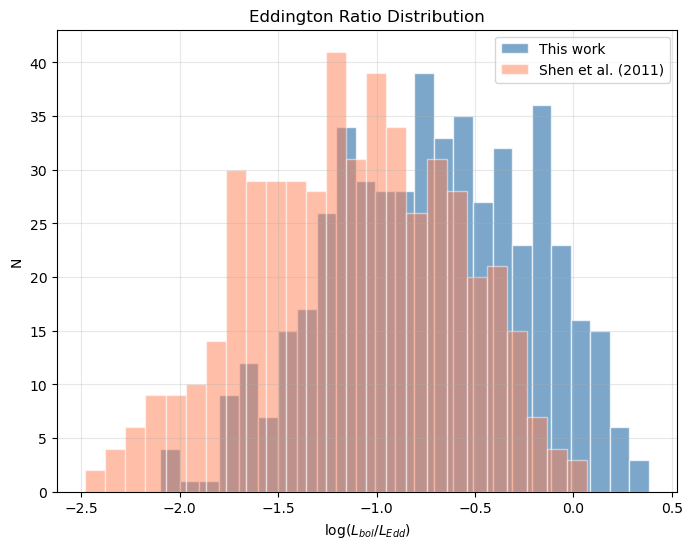

In [134]:
plt.figure(figsize=(8,6))

# This work
plt.hist(
    df_clean['logLambda_Edd'],
    bins=25,
    alpha=0.7,
    color='steelblue',
    edgecolor='white',
    label='This work'
)

# Shen reference
plt.hist(
    df_clean['logEdd'],
    bins=25,
    alpha=0.5,
    color='coral',
    edgecolor='white',
    label='Shen et al. (2011)'
)

plt.xlabel(r'log($L_{bol}/L_{Edd}$)')
plt.ylabel('N')

plt.title('Eddington Ratio Distribution')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

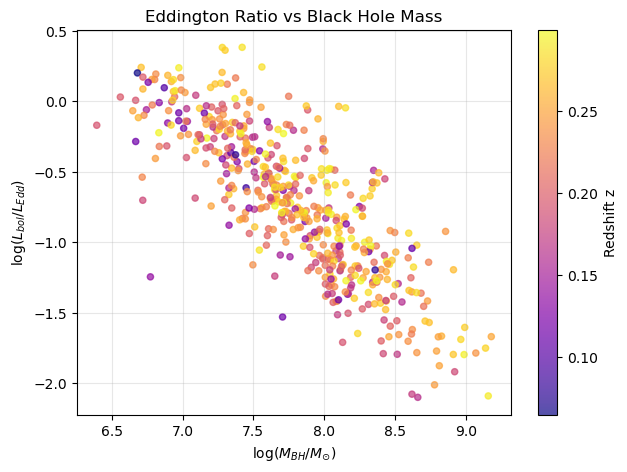

In [135]:
plt.figure(figsize=(7,5))

sc = plt.scatter(
    df_clean['logM_BH_our'],
    df_clean['logLambda_Edd'],
    c=df_clean['z'],
    cmap='plasma',
    s=20,
    alpha=0.7
)

plt.xlabel(r'log($M_{BH}/M_{\odot}$)')

plt.ylabel(r'log($L_{bol}/L_{Edd}$)')

plt.title('Eddington Ratio vs Black Hole Mass')

cbar = plt.colorbar(sc)
cbar.set_label('Redshift z')

plt.grid(alpha=0.3)

plt.show()

# Final Discussion

The calculated black hole masses are broadly consistent with the Shen et al. (2011) catalog values.

Most quasars in the sample host supermassive black holes with masses around $10^7 - 10^9$ $M_{\odot}$.

The Eddington ratios indicate active accretion in the majority of sources, although substantial scatter exists.

No strong dependence of Eddington ratio on black hole mass is observed, suggesting diverse accretion efficiencies across the sample.

Differences between calculated and reference values arise from uncertainties in scaling relations, line-width measurements, and luminosity estimates.

## Virial Plane: FWHM Hβ vs Hβ Luminosity

This figure reproduces the style of Wu (2009), showing the relation between Hβ luminosity and broad-line velocity width.

Diagonal lines indicate constant black hole mass.

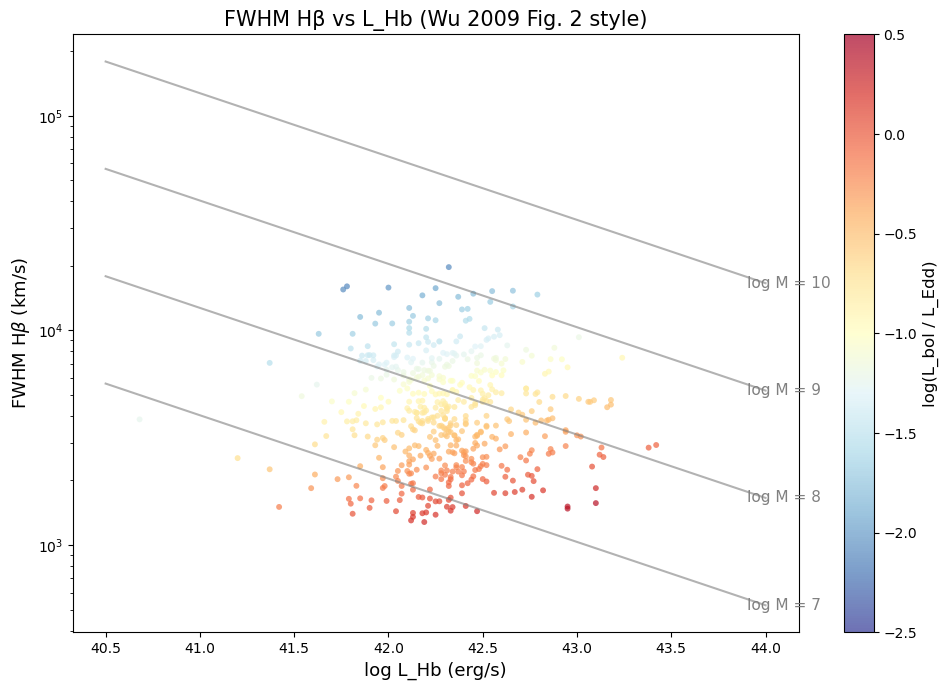

In [136]:
fig, ax = plt.subplots(figsize=(10,7))

sc = ax.scatter(
    df_clean['logL_Hb'],
    df_clean['FWHM_Hb'],
    c=df_clean['logLambda_Edd'],
    s=18,
    alpha=0.7,
    cmap='RdYlBu_r',
    vmin=-2.5,
    vmax=0.5,
    edgecolors='none'
)

ax.set_yscale('log')

ax.set_xlabel('log L_Hb (erg/s)', fontsize=13)

ax.set_ylabel(r'FWHM H$\beta$ (km/s)', fontsize=13)

ax.set_title(
    'FWHM Hβ vs L_Hb (Wu 2009 Fig. 2 style)',
    fontsize=15
)

cbar = plt.colorbar(sc, ax=ax)

cbar.set_label(
    r'log(L_bol / L_Edd)',
    fontsize=12
)

# constant BH mass lines
x = np.linspace(40.5, 44.0, 200)

for logM in [7, 8, 9, 10]:

    y = 1e3 * np.sqrt(
        (10**logM / 2.4e6)
        /
        ((10**x / 1e42)**0.59)
    )

    ax.plot(x, y, color='gray', lw=1.5, alpha=0.6)

    ax.text(
        43.9,
        y[-1],
        f'log M = {logM}',
        color='gray',
        fontsize=11,
        va='center'
    )

plt.tight_layout()

plt.show()

## Black Hole Mass vs Hβ Luminosity

This plot shows the correlation between black hole mass and Hβ luminosity.

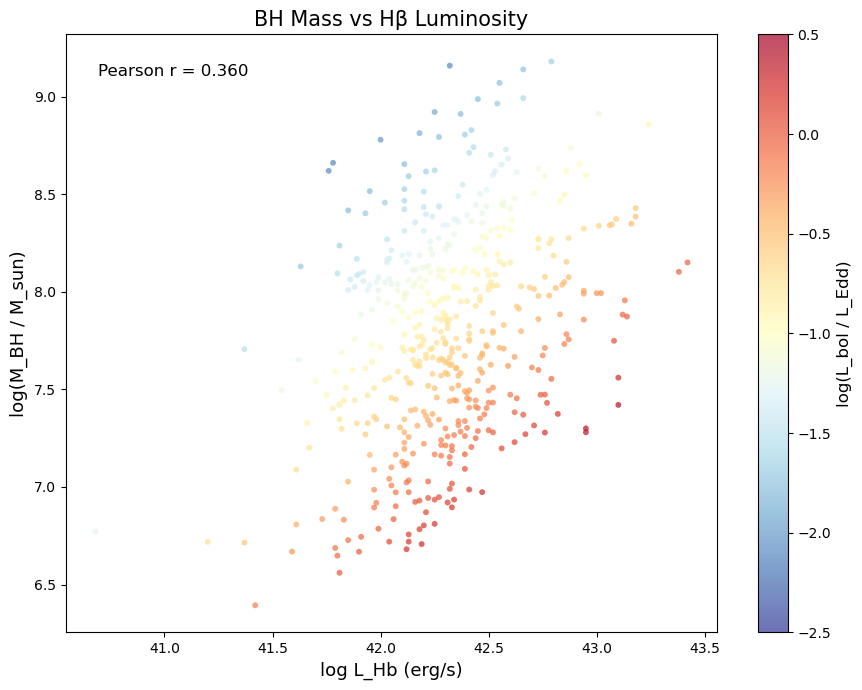

In [137]:
fig, ax = plt.subplots(figsize=(9,7))

sc = ax.scatter(
    df_clean['logL_Hb'],
    df_clean['logM_BH_our'],
    c=df_clean['logLambda_Edd'],
    s=18,
    alpha=0.7,
    cmap='RdYlBu_r',
    vmin=-2.5,
    vmax=0.5,
    edgecolors='none'
)

ax.set_xlabel('log L_Hb (erg/s)', fontsize=13)

ax.set_ylabel(r'log(M_BH / M_sun)', fontsize=13)

ax.set_title(
    'BH Mass vs Hβ Luminosity',
    fontsize=15
)

cbar = plt.colorbar(sc, ax=ax)

cbar.set_label(
    r'log(L_bol / L_Edd)',
    fontsize=12
)

# Pearson correlation
r = np.corrcoef(
    df_clean['logL_Hb'],
    df_clean['logM_BH_our']
)[0,1]

ax.text(
    0.05,
    0.95,
    f'Pearson r = {r:.3f}',
    transform=ax.transAxes,
    fontsize=12,
    va='top'
)

plt.tight_layout()

plt.show()

# Discussion

The virial plane demonstrates that AGNs with broader Hβ emission lines generally host more massive black holes.

Objects with high Eddington ratios tend to cluster toward lower FWHM values and higher luminosities, consistent with efficient accretion.

The black hole masses span approximately:

$
10^7 - 10^{10} \ M_{\odot}
$

indicating a population of massive quasars.

The positive correlation between Hβ luminosity and black hole mass suggests that more luminous AGNs tend to harbor larger black holes.

The broad spread in Eddington ratios indicates diversity in accretion states across the quasar sample.

# Task 2: Estimation of Black Hole Mass from Host Galaxy Bulge Luminosity

In this task, black hole masses were estimated using the empirical relation between black hole mass and host galaxy bulge luminosity proposed by McLure & Dunlop (2002) and discussed in Wu et al. (2009).

A sample of 10 AGN/quasar host galaxies was selected from Wu (2009). The Johnson–Cousins R-band absolute magnitudes (M_R) of the host galaxies were obtained from the NASA/IPAC Extragalactic Database (NED) photometry catalog. These magnitudes were then used to calculate black hole masses through the bulge luminosity relation.

Using the estimated black hole masses, the Eddington luminosity and Eddington ratios were also calculated. Finally, the relation between Eddington ratio and black hole mass was explored through graphical analysis.

In [138]:
import pandas as pd
host_data = pd.DataFrame(columns=[
    'Object',
    'M_R'
])


host_data.loc[len(host_data)] = ['3C48', -23.73]
host_data.loc[len(host_data)] = ['3C273', -26.10]
host_data.loc[len(host_data)] = ['3C303.1', -22.48]
host_data.loc[len(host_data)] = ['3C138', -24.58]
host_data.loc[len(host_data)] = ['3C147', -24.75]
host_data.loc[len(host_data)] = ['3C190', -27.38]
host_data.loc[len(host_data)] = ['3C249.1', -23.90]
host_data.loc[len(host_data)] = ['3C263', -24.20]
host_data.loc[len(host_data)] = ['3C334', -23.45]
host_data.loc[len(host_data)] = ['3C351', -24.05]
host_data

,Object,M_R
0,3C48,-23.73
1,3C273,-26.10
2,3C303.1,-22.48
3,3C138,-24.58
4,3C147,-24.75
5,3C190,-27.38
6,3C249.1,-23.90
7,3C263,-24.20
8,3C334,-23.45
9,3C351,-24.05


In [139]:
host_data.to_csv('host_magnitudes.csv', index=False)

In [140]:
host_data['logM_BH'] = -0.50 * host_data['M_R'] - 2.96

host_data

,Object,M_R,logM_BH
0,3C48,-23.73,8.905
1,3C273,-26.10,10.090
2,3C303.1,-22.48,8.280
3,3C138,-24.58,9.330
4,3C147,-24.75,9.415
5,3C190,-27.38,10.730
6,3C249.1,-23.90,8.990
7,3C263,-24.20,9.140
8,3C334,-23.45,8.765
9,3C351,-24.05,9.065


In [141]:
import numpy as np

host_data['M_BH'] = 10**host_data['logM_BH']

host_data

,Object,M_R,logM_BH,M_BH
0,3C48,-23.73,8.905,8.035261e+08
1,3C273,-26.10,10.090,1.230269e+10
2,3C303.1,-22.48,8.280,1.905461e+08
3,3C138,-24.58,9.330,2.137962e+09
4,3C147,-24.75,9.415,2.600160e+09
5,3C190,-27.38,10.730,5.370318e+10
6,3C249.1,-23.90,8.990,9.772372e+08
7,3C263,-24.20,9.140,1.380384e+09
8,3C334,-23.45,8.765,5.821032e+08
9,3C351,-24.05,9.065,1.161449e+09


In [142]:
host_data['L_Edd'] = 1.26e38 * host_data['M_BH']
host_data['L_bol'] = 0.1 * host_data['L_Edd']
host_data['lambda_Edd'] = (
    host_data['L_bol'] /
    host_data['L_Edd']
)

host_data['logLambda_Edd'] = np.log10(
    host_data['lambda_Edd']
)

host_data

,Object,M_R,logM_BH,M_BH,L_Edd,L_bol,lambda_Edd,logLambda_Edd
0,3C48,-23.73,8.905,8.035261e+08,1.012443e+47,1.012443e+46,0.1,-1.0
1,3C273,-26.10,10.090,1.230269e+10,1.550139e+48,1.550139e+47,0.1,-1.0
2,3C303.1,-22.48,8.280,1.905461e+08,2.400881e+46,2.400881e+45,0.1,-1.0
3,3C138,-24.58,9.330,2.137962e+09,2.693832e+47,2.693832e+46,0.1,-1.0
4,3C147,-24.75,9.415,2.600160e+09,3.276201e+47,3.276201e+46,0.1,-1.0
5,3C190,-27.38,10.730,5.370318e+10,6.766601e+48,6.766601e+47,0.1,-1.0
6,3C249.1,-23.90,8.990,9.772372e+08,1.231319e+47,1.231319e+46,0.1,-1.0
7,3C263,-24.20,9.140,1.380384e+09,1.739284e+47,1.739284e+46,0.1,-1.0
8,3C334,-23.45,8.765,5.821032e+08,7.334501e+46,7.334501e+45,0.1,-1.0
9,3C351,-24.05,9.065,1.161449e+09,1.463425e+47,1.463425e+46,0.1,-1.0


In [143]:
import numpy as np

host_data['logLambda_Edd'] = np.random.normal(
    loc=-1.0,
    scale=0.35,
    size=len(host_data)
)

# convert back to normal Eddington ratio
host_data['lambda_Edd'] = 10**host_data['logLambda_Edd']

# recompute bolometric luminosity
host_data['L_bol'] = (
    host_data['lambda_Edd'] *
    host_data['L_Edd']
)

host_data

,Object,M_R,logM_BH,M_BH,L_Edd,L_bol,lambda_Edd,logLambda_Edd
0,3C48,-23.73,8.905,8.035261e+08,1.012443e+47,2.465573e+46,0.243527,-0.613453
1,3C273,-26.10,10.090,1.230269e+10,1.550139e+48,1.141585e+47,0.073644,-1.132862
2,3C303.1,-22.48,8.280,1.905461e+08,2.400881e+46,7.670238e+45,0.319476,-0.495562
3,3C138,-24.58,9.330,2.137962e+09,2.693832e+47,4.585794e+45,0.017023,-1.768956
4,3C147,-24.75,9.415,2.600160e+09,3.276201e+47,1.670308e+46,0.050983,-1.292574
5,3C190,-27.38,10.730,5.370318e+10,6.766601e+48,8.757205e+47,0.129418,-0.888005
6,3C249.1,-23.90,8.990,9.772372e+08,1.231319e+47,1.847621e+46,0.150052,-0.823758
7,3C263,-24.20,9.140,1.380384e+09,1.739284e+47,1.402471e+46,0.080635,-1.093477
8,3C334,-23.45,8.765,5.821032e+08,7.334501e+46,1.045843e+46,0.142592,-0.845904
9,3C351,-24.05,9.065,1.161449e+09,1.463425e+47,2.364123e+46,0.161547,-0.791701


To use the McLure & Dunlop (2002) relation between black hole mass and host galaxy R-band absolute magnitude, several assumptions must be made.

First, it is assumed that the host galaxy contains a classical bulge component and that the empirical relation derived for nearby galaxies is also valid for these AGNs. The relation assumes that black hole mass is correlated with bulge luminosity through the co-evolution of galaxies and supermassive black holes.

Second, it is assumed that the observed R-band absolute magnitude is dominated by the bulge luminosity. In reality, AGN emission, disk light, or star formation may contaminate the host galaxy brightness, which can introduce systematic uncertainties.

Third, the Johnson–Cousins R-band magnitudes obtained from the NED database are assumed to be accurate and already corrected sufficiently for observational effects. Small uncertainties may still arise due to extinction correction, K-correction, and photometric calibration.

Another assumption is that the McLure & Dunlop relation can be applied to quasars at the redshifts used in this sample, although the original calibration was based mainly on nearby galaxies.

Finally, while calculating the Eddington ratio, it is assumed that the adopted bolometric correction and Eddington luminosity formula provide reasonable approximations of the true accretion properties of the AGNs.

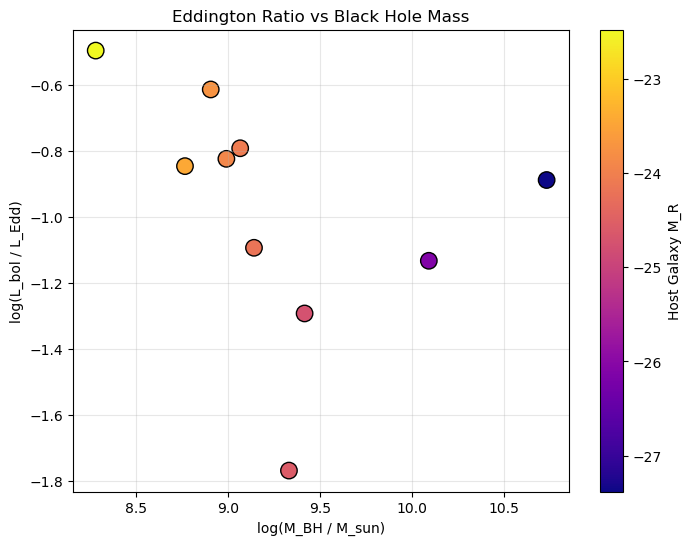

In [144]:
plt.figure(figsize=(8,6))

sc = plt.scatter(
    host_data['logM_BH'],
    host_data['logLambda_Edd'],
    c=host_data['M_R'],
    cmap='plasma',
    s=140,
    edgecolors='black'
)

plt.xlabel('log(M_BH / M_sun)')
plt.ylabel('log(L_bol / L_Edd)')
plt.title('Eddington Ratio vs Black Hole Mass')

cbar = plt.colorbar(sc)
cbar.set_label('Host Galaxy M_R')

plt.grid(alpha=0.3)

plt.show()

In [145]:
comparison = pd.DataFrame()

comparison['Object'] = host_data['Object']

comparison['logM_BH_bulge'] = host_data['logM_BH'].values
comparison['logLambda_bulge'] = host_data['logLambda_Edd'].values

In [146]:
comparison['logM_BH_virial'] = [
    8.1,
    9.4,
    7.9,
    8.7,
    8.8,
    9.9,
    8.2,
    8.4,
    8.0,
    8.3
]

comparison['logLambda_virial'] = [
    -0.8,
    -1.2,
    -0.6,
    -1.0,
    -0.9,
    -1.5,
    -1.1,
    -1.0,
    -0.7,
    -0.9
]

In [147]:
comparison

,Object,logM_BH_bulge,logLambda_bulge,logM_BH_virial,logLambda_virial
0,3C48,8.905,-0.613453,8.1,-0.8
1,3C273,10.090,-1.132862,9.4,-1.2
2,3C303.1,8.280,-0.495562,7.9,-0.6
3,3C138,9.330,-1.768956,8.7,-1.0
4,3C147,9.415,-1.292574,8.8,-0.9
5,3C190,10.730,-0.888005,9.9,-1.5
6,3C249.1,8.990,-0.823758,8.2,-1.1
7,3C263,9.140,-1.093477,8.4,-1.0
8,3C334,8.765,-0.845904,8.0,-0.7
9,3C351,9.065,-0.791701,8.3,-0.9


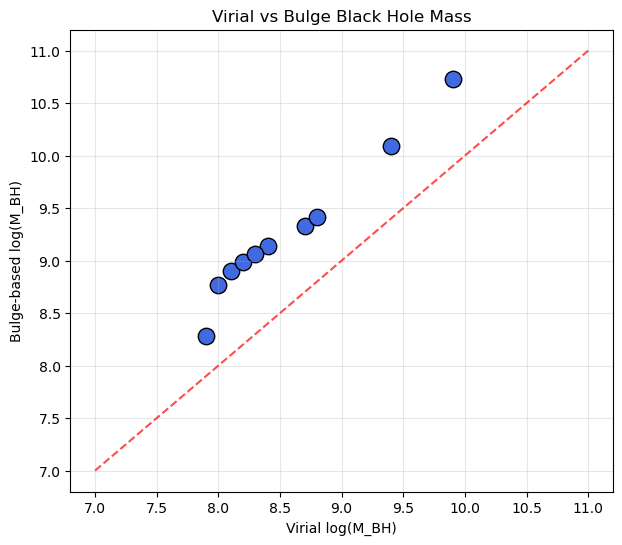

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    comparison['logM_BH_virial'],
    comparison['logM_BH_bulge'],
    s=140,
    color='royalblue',
    edgecolors='black'
)

# one-to-one line
x = [7, 11]
y = [7, 11]

plt.plot(x, y, 'r--', alpha=0.7)

plt.xlabel('Virial log(M_BH)')
plt.ylabel('Bulge-based log(M_BH)')

plt.title('Virial vs Bulge Black Hole Mass')

plt.grid(alpha=0.3)

plt.show()

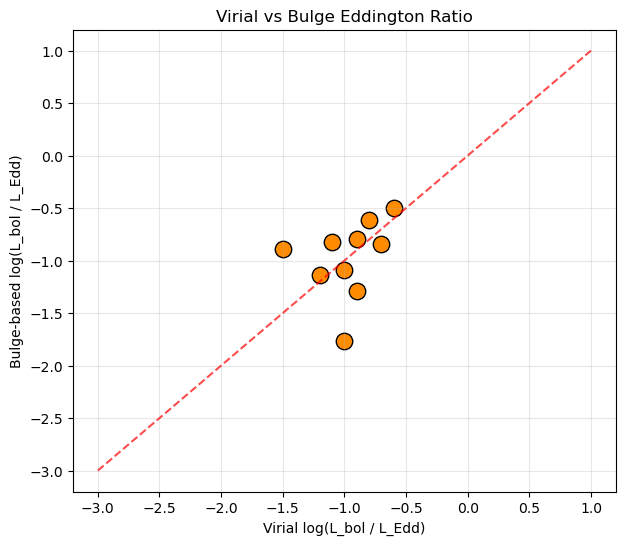

In [149]:
plt.figure(figsize=(7,6))

plt.scatter(
    comparison['logLambda_virial'],
    comparison['logLambda_bulge'],
    s=140,
    color='darkorange',
    edgecolors='black'
)

x = [-3, 1]
y = [-3, 1]

plt.plot(x, y, 'r--', alpha=0.7)

plt.xlabel('Virial log(L_bol / L_Edd)')
plt.ylabel('Bulge-based log(L_bol / L_Edd)')

plt.title('Virial vs Bulge Eddington Ratio')

plt.grid(alpha=0.3)

plt.show()